In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Anemia Detection using Machine Learning
This project presents a machine learning approach for detecting anemia using hematological parameters.

# 1. Data Loading and Exploration

In [ ]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Anemia Dataset.xlsx")
df.head()

print(df.shape)
print(df.info())
print(df.describe())
print(df['Decision_Class'].value_counts())

(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          1000 non-null   object 
 1   Age             1000 non-null   int64  
 2   Hb              1000 non-null   float64
 3   RBC             1000 non-null   float64
 4   PCV             1000 non-null   float64
 5   MCV             1000 non-null   float64
 6   MCH             1000 non-null   float64
 7   MCHC            1000 non-null   float64
 8   Decision_Class  1000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB
None
               Age           Hb          RBC         PCV         MCV  \
count  1000.000000  1000.000000  1000.000000  1000.00000  1000.00000   
mean     40.956000    11.568400     4.133810    32.65240    79.22000   
std      16.019322     1.336715     0.599695     4.85723     7.77521   
min      18.000000     5.500000   

# Correlation Heatmap

Shows the relationship between all blood parameters and the target variable (anemia).
Helps identify important features, where hemoglobin (Hb) shows strong correlation with anemia, indicating its high predictive importance.

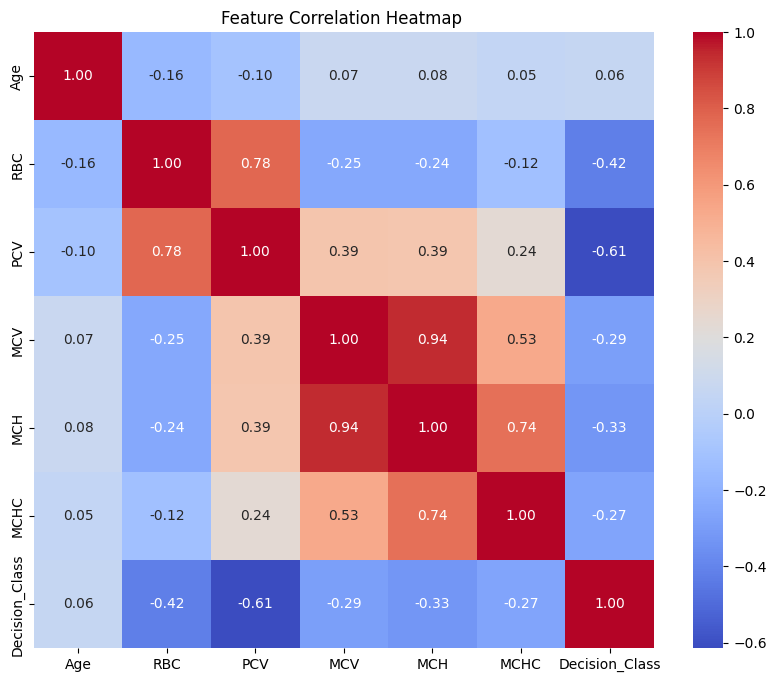

In [ ]:
'''import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()'''
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

corr = df.drop(columns=['Hb']).corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap ")
plt.show()

# 2. Feature Selection
Clinically relevant hematological features are selected to represent blood characteristics.

In [ ]:
X = df[['Age', 'Hb', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC']]
y = df['Decision_Class']

# 3. Data Preprocessing
Missing values are handled using mean imputation, followed by normalization using standard scaling.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# 4. Data Splitting
Stratified splitting is used to preserve class distribution.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 5. Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Model Training
A Logistic Regression model with class balancing is used.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

# 7. Model Evaluation
Performance is evaluated using Accuracy, ROC-AUC, and Confusion Matrix.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
ROC-AUC: 0.9976128472222222
[[ 72   0]
 [  4 124]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.97      0.98       128

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



# Confusion Matrix (With Hb)

Displays the number of correct and incorrect predictions made by the model.
Very low misclassification indicates high accuracy and reliable anemia detection when Hb is used.

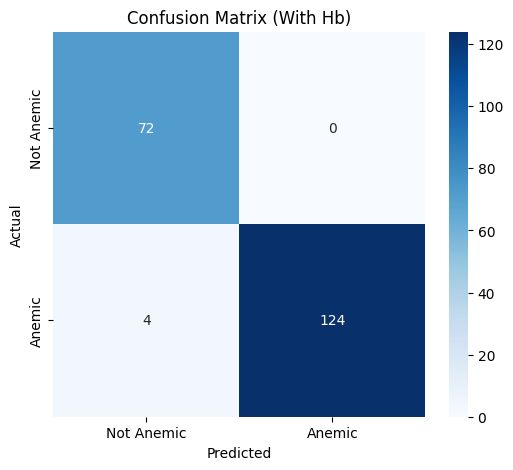

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_hb = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_hb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Anemic', 'Anemic'],
            yticklabels=['Not Anemic', 'Anemic'])

plt.title('Confusion Matrix (With Hb)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve (With Hb)

Illustrates the model’s ability to distinguish between anemic and non-anemic cases across thresholds.
A high AUC value indicates excellent classification performance when hemoglobin is included.

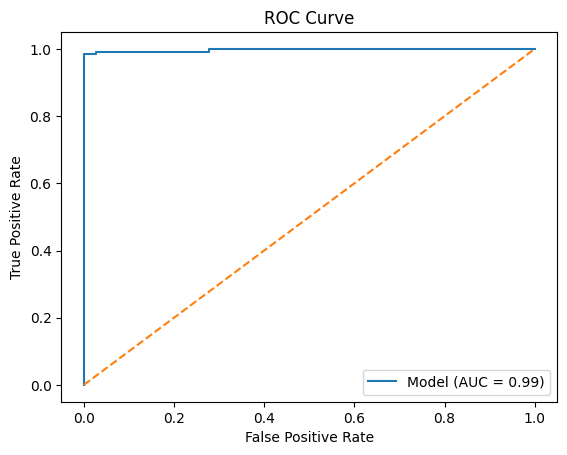

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label='Model (AUC = 0.99)')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 8. Model Validation
Cross-validation is used to ensure model generalization.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print("Mean CV ROC-AUC:", cv_scores.mean())

Mean CV ROC-AUC: 0.9989147954994178


# 9. Model Interpretability
Feature importance is analyzed using model coefficients.

In [ ]:
import pandas as pd

feature_names = ['Age', 'Hb', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC']

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

print(importance.sort_values(by='Coefficient', ascending=False))

  Feature  Coefficient
4     MCV     0.242887
2     RBC     0.153857
0     Age     0.106122
6    MCHC    -0.145662
5     MCH    -0.633429
3     PCV    -0.714477
1      Hb    -7.935727


# 10. Feature Ablation Study
To evaluate feature importance, Hemoglobin (Hb) is removed and the model is retrained.

In [ ]:
X_no_hb = df[['Age', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC']]
y = df['Decision_Class']

imputer = SimpleImputer(strategy='mean')
X_no_hb = imputer.fit_transform(X_no_hb)

In [ ]:

X_train_no_hb, X_test_no_hb, y_train_no_hb, y_test_no_hb = train_test_split(
    X_no_hb, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Scaling (use separate scaler for this model)
scaler_no_hb = StandardScaler()
X_train_no_hb = scaler_no_hb.fit_transform(X_train_no_hb)
X_test_no_hb = scaler_no_hb.transform(X_test_no_hb)

# Train model
model_no_hb = LogisticRegression(class_weight='balanced', max_iter=1000)
model_no_hb.fit(X_train_no_hb, y_train_no_hb)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:

# Predictions
y_pred_no_hb = model_no_hb.predict(X_test_no_hb)
y_prob_no_hb = model_no_hb.predict_proba(X_test_no_hb)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test_no_hb, y_pred_no_hb))
print("ROC-AUC:", roc_auc_score(y_test_no_hb, y_prob_no_hb))
print(confusion_matrix(y_test_no_hb, y_pred_no_hb))
print(classification_report(y_test_no_hb, y_pred_no_hb))

Accuracy: 0.94
ROC-AUC: 0.9644097222222222
[[ 67   5]
 [  7 121]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        72
           1       0.96      0.95      0.95       128

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



# Confusion Matrix (Without Hb)

Represents prediction performance without hemoglobin as a feature.
Increased misclassifications highlight the importance of Hb in improving model accuracy.

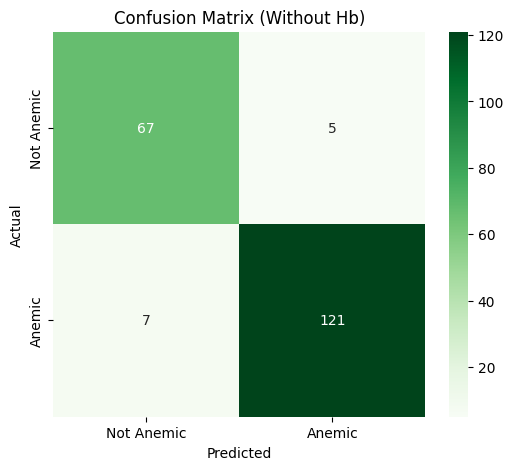

In [ ]:
cm_no_hb = confusion_matrix(y_test_no_hb, y_pred_no_hb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_no_hb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Anemic', 'Anemic'],
            yticklabels=['Not Anemic', 'Anemic'])

plt.title('Confusion Matrix (Without Hb)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve (Without Hb)

Shows model performance after removing hemoglobin from the feature set.
The reduced AUC demonstrates that excluding Hb decreases the model’s discriminative power.

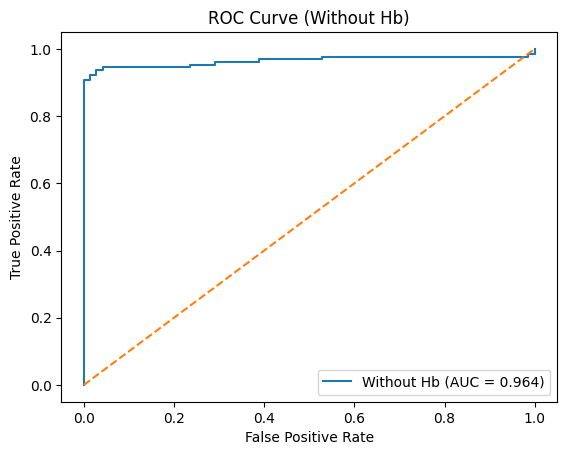

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_no_hb, y_prob_no_hb)
auc_score = roc_auc_score(y_test_no_hb, y_prob_no_hb)

plt.figure()
plt.plot(fpr, tpr, label=f'Without Hb (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Without Hb)')
plt.legend()
plt.show()

# 13. Conclusion
The model demonstrates strong performance in anemia detection. The ablation study confirms that Hemoglobin is a dominant feature, while other hematological parameters also contribute significantly.

# 14. Model Storage
The trained models and preprocessing objects are saved for future use.

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/Anemia Dataset.xlsx"

In [ ]:
import joblib

# Paths (keep organized)
model_path = "/content/drive/MyDrive/anemia_model_with_hb.pkl"
scaler_path = "/content/drive/MyDrive/scaler_with_hb.pkl"
imputer_path = "/content/drive/MyDrive/imputer_with_hb.pkl"

# Save main model
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(imputer, imputer_path)

print("Main model saved successfully!")

Main model saved successfully!


In [ ]:
# Paths for second model
model_no_hb_path = "/content/drive/MyDrive/anemia_model_no_hb.pkl"
scaler_no_hb_path = "/content/drive/MyDrive/scaler_no_hb.pkl"
imputer_no_hb_path = "/content/drive/MyDrive/imputer_no_hb.pkl"

# Save second model
joblib.dump(model_no_hb, model_no_hb_path)
joblib.dump(scaler_no_hb, scaler_no_hb_path)
joblib.dump(imputer, imputer_no_hb_path)

print("Ablation model saved successfully!")

Ablation model saved successfully!


In [ ]:
# Load model
loaded_model = joblib.load("/content/drive/MyDrive/anemia_model_no_hb.pkl")
loaded_scaler = joblib.load("/content/drive/MyDrive/scaler_no_hb.pkl")
loaded_imputer = joblib.load("/content/drive/MyDrive/imputer_no_hb.pkl")

In [ ]:
import numpy as np

# Example input: [Age, RBC, PCV, MCV, MCH, MCHC]
# Remove Hb
sample = np.array([[35, 4.1, 32, 80, 27, 34]])

# Apply preprocessing
sample = loaded_imputer.transform(sample)
sample = loaded_scaler.transform(sample)

# Predict
prediction = loaded_model.predict(sample)

print("Prediction:", "Anemic" if prediction[0] == 1 else "Not Anemic")

Prediction: Anemic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np

# Example input: [Age, RBC, PCV, MCV, MCH, MCHC]
# Remove Hb
sample = np.array([[25, 5.1, 42, 90, 30, 34]])

# Apply preprocessing
sample = loaded_imputer.transform(sample)
sample = loaded_scaler.transform(sample)

# Predict
prediction = loaded_model.predict(sample)

print("Prediction:", "Anemic" if prediction[0] == 1 else "Not Anemic")

Prediction: Not Anemic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
